# The GLP-1 / Ozempic basket — a quantitative teardown 🔬
### Mean-excess & market-model α vs SPY and XLV (HAC-*t*) · single-name decomposition · a 2023 recency split · block-bootstrap CI · cost sweep · a planted-α synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Two_stocks_and_a_story%3F: Misattributed](https://img.shields.io/badge/Two_stocks_and_a_story%3F-Misattributed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The "Ozempic trade" (50/50 **LLY/NVO**) beats SPY and XLV on raw return — but we separate three things the pitch fuses: a **statistically robust** edge (it isn't, vs SPY: HAC-*t* ≈ 1.1), a **theme** edge (it's one name — LLY *t*=2.7, NVO *t*=0.3), and a **durable** edge (the excess flips *negative* during the 2023–26 mania). Signal is **WEAK**, the attribution is **MISATTRIBUTED**, and the book is a **MIRAGE** of concentrated beta.

> ⚠️ **Not investment advice.** Real data: yfinance adjusted-close (total return) for LLY, **NVO (US ADR)**, XLV, SPY, 2018→2026. The offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from glp1_basket import data, strategy as st

HAVE_REAL = data.have_real()
P = data.load_real() if HAVE_REAL else None
RET = data.daily_returns(P) if HAVE_REAL else None
BK = data.basket_returns(RET) if HAVE_REAL else None
print("real yfinance panel cache present:", HAVE_REAL,
      "| daily returns:", (0 if RET is None else len(RET)))

# frozen headline numbers (mirror of docs/results.md)
R = {'window': '2018-01-02 → 2026-06-18', 'n': 2126, 'lly_cagr': 36.9, 'lly_vol': 31.8, 'lly_sh': 1.16, 'lly_tot': 1366.8, 'lly_dd': -34.5, 'nvo_cagr': 13.5, 'nvo_vol': 33.5, 'nvo_sh': 0.4, 'nvo_tot': 93.0, 'nvo_dd': -74.7, 'bk_cagr': 25.2, 'bk_vol': 27.4, 'bk_sh': 0.92, 'bk_tot': 510.7, 'bk_dd': -49.3, 'xlv_cagr': 10.1, 'xlv_vol': 17.4, 'xlv_sh': 0.58, 'xlv_tot': 105.4, 'xlv_dd': -28.4, 'spy_cagr': 15.5, 'spy_vol': 19.2, 'spy_sh': 0.81, 'spy_tot': 216.5, 'spy_dd': -33.7, 'ex_spy': 9.68, 't_spy': 1.1, 'ex_xlv': 15.14, 't_xlv': 2.01, 'alpha_spy': 15.18, 'ta_spy': 1.78, 'beta_spy': 0.65, 'alpha_xlv': 15.45, 'ta_xlv': 2.05, 'beta_xlv': 0.97, 'boot_pt': 15.1, 'boot_lo': 0.2, 'boot_hi': 29.3, 'boot_p': 0.976, 'lly_alpha': 26.58, 'lly_ta': 2.66, 'lly_beta': 0.66, 'nvo_alpha': 3.77, 'nvo_ta': 0.35, 'nvo_beta': 0.63, 'nvo_peak': 137.4, 'nvo_last': 43.2, 'nvo_dd_peak': -69, 'corr_llynvo': 0.4, 'corr_bk_spy': 0.45, 'corr_bk_xlv': 0.62, 'pre_bk': 29.9, 'pre_spy': 11.1, 'pre_ex': 18.8, 'pre_t': 1.93, 'pre_n': 1258, 'post_bk': 18.4, 'post_spy': 21.9, 'post_ex': -3.5, 'post_t': -0.21, 'post_n': 868, 'turnover': 0.367, 'cost10_ex': 15.04, 'cost10_t': 2.0, 'syn': [('LLY', 25.2, 33.8, 4.33), ('NVO', 0.0, -2.9, -0.39), ('XLV', 5.0, 9.7, 1.21)]}


real yfinance panel cache present: True | daily returns: 2126


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Mean excess vs SPY +9.7%/yr at **HAC-*t* = 1.10** (< 2); market-model α vs SPY +15.2%/yr, *t* = 1.78. Only vs XLV is it borderline (α *t* = 2.05), with a bootstrap CI **[+0.2%, +29.3%]** grazing zero. |
| **Tradability** | `MIRAGE` | Two-name book (corr LLY–NVO 0.40), basket max-DD **-49%**. Turnover 0.37%/day → cost is immaterial (net-of-10bp α still +15.0%/yr): the killer is concentration, not the spread. |
| **Two stocks & a story?** | `MISATTRIBUTED` | α is **all LLY** (+26.6%/yr, *t* = 2.66); **NVO** +3.8%/yr, *t* = 0.35 (≈0), -69% from peak. Excess flips to **-3.5%/yr** in 2023–26. |

> 💡 In plain words: the basket out-returned the market, but the out-performance is within noise vs SPY, lives entirely in one stock, and disappeared exactly when the theme became famous. Three different ways of saying *not an edge.*

## 1 · The claim, steelmanned

Let the basket's daily total return be $r^{\text{bk}}_t = \tfrac12 r^{\text{LLY}}_t + \tfrac12 r^{\text{NVO}}_t$ and a benchmark $r^{b}_t \in \{r^{\text{SPY}}, r^{\text{XLV}}\}$. The theme makes three claims:

- **H₁ (real alpha).** Mean excess $\bar{x} = \overline{r^{\text{bk}} - r^{b}} > 0$ with an autocorrelation-robust $t \ge 2$; and the CAPM intercept $\alpha$ in $r^{\text{bk}} = \alpha + \beta r^{b} + \varepsilon$ is positive and significant.
- **H₂ (it is the theme, not a name).** The α is **broad** — not concentrated in a single constituent.
- **H₃ (durable).** The edge is present in the period the theme is about (the 2023+ GLP-1 mania), not only before it.

We find **H₁ weak** (vs SPY $t\approx1.1$; vs XLV borderline and bootstrap-fragile), **H₂ rejected** (α is entirely LLY), **H₃ rejected** (excess turns negative post-2023). The trade is true on *raw return* and false on every axis that would make it an edge.

## 2 · So what? — what rides on each answer

Raw out-performance is cheap: high-β single names beat a broad index in a bull market by construction. The identity that matters is

$$ r^{\text{bk}}_t = \underbrace{\alpha}_{\text{skill?}} + \underbrace{\beta\, r^{b}_t}_{\text{paid-for beta}} + \varepsilon_t, \qquad H_0:\ \alpha = 0. $$

Three confounds sit on top of it. **(i) Beta** — the basket's β to SPY is ~0.65, so much of the return is just market exposure. **(ii) Selection** — LLY and NVO are in the basket *because* they won; conditioning on realised winners biases $\hat\alpha$ **upward** (Brown et al. 1992). **(iii) Concentration** — a 2-name book's $\hat\alpha$ has huge idiosyncratic variance, so even a large point estimate can carry a tiny *t*. Measuring *raw* return alone settles none of these; the HAC-*t* on α does.

## 3 · How we'd know — the protocol

- **Real tape.** yfinance **adjusted close** (total return), 2018-01-02 → 2026-06-18, 2,126 daily returns. NVO is the **US ADR** (the line a US reader trades — named as a proxy for the Copenhagen B-share, which differs by FX/ADR effects).
- **Signal test (H₁).** Mean excess vs SPY and XLV with a **Newey-West (HAC)** *t* (Bartlett kernel, automatic lag $\lfloor 4(n/100)^{2/9}\rfloor$); plus a market-model α with a **HAC-*t* on the intercept**. A circular-**block bootstrap** (21-day blocks) gives the excess-return CI. Bar: **HAC-*t* ≥ 2** on the *real* tape to be `REAL`.
- **Decomposition (H₂).** The same market model per single name vs SPY — does the α live in one constituent?
- **Recency (H₃).** Split at 2023-01-01 (a *justified*, not snooped, break: the GLP-1 story's mainstreaming) and re-test the excess each side.
- **Tradability.** One-way cost sweep on rebalancing turnover, and the basket/constituent drawdowns (concentration risk).
- **Positive control.** A fixed-seed one-factor panel with a *planted* per-name α — the engine must recover it (LLY-like) and the *absence* of it (NVO-like).

**Mirage condition (pre-registered):** HAC-*t* on α below 2 vs SPY, α concentrated in one name, and/or the excess vanishing in the post-2023 sub-period.

## 4 · The teardown

### 4a · The signal is WEAK — mean excess & α under HAC inference

Annualised excess / α vs each benchmark, with the HAC-*t* printed against the bar (2).

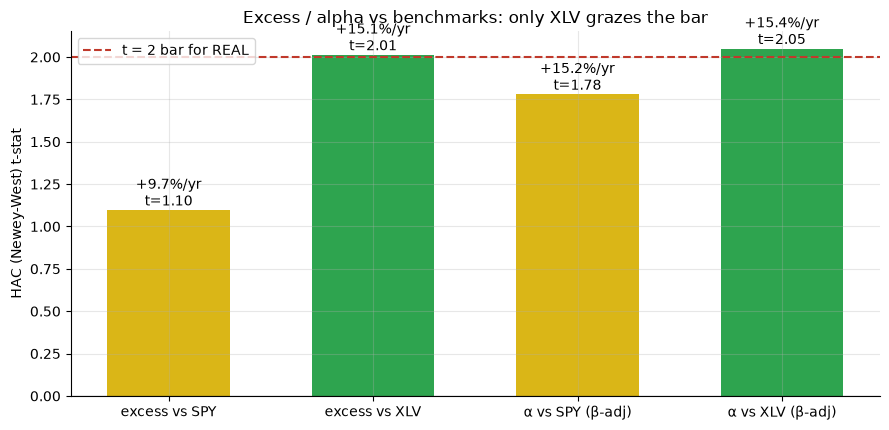

excess vs SPY: t=1.10   excess vs XLV: t=2.01   α vs SPY (β-adj): t=1.78   α vs XLV (β-adj): t=2.05


In [2]:
if HAVE_REAL:
    eS = st.excess_test(BK, RET['SPY']); eX = st.excess_test(BK, RET['XLV'])
    aS = st.market_model(BK, RET['SPY']); aX = st.market_model(BK, RET['XLV'])
    rows = [('excess vs SPY', eS['ann_excess']*100, eS['t_hac']),
            ('excess vs XLV', eX['ann_excess']*100, eX['t_hac']),
            ('α vs SPY (β-adj)', aS['alpha_ann']*100, aS['t_alpha']),
            ('α vs XLV (β-adj)', aX['alpha_ann']*100, aX['t_alpha'])]
else:
    rows = [('excess vs SPY', R['ex_spy'], R['t_spy']),('excess vs XLV', R['ex_xlv'], R['t_xlv']),
            ('α vs SPY (β-adj)', R['alpha_spy'], R['ta_spy']),('α vs XLV (β-adj)', R['alpha_xlv'], R['ta_xlv'])]
labels=[r[0] for r in rows]; ts=[r[2] for r in rows]
fig, ax = plt.subplots(figsize=(9.0,4.4))
cols=[GREEN if t>=2 else AMBER for t in ts]
bars=ax.bar(labels, ts, color=cols, width=.6)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar for REAL'); ax.axhline(0,c='k',lw=.8)
ax.set_ylabel('HAC (Newey-West) t-stat'); ax.set_title('Excess / alpha vs benchmarks: only XLV grazes the bar')
for b,(l,v,t) in zip(bars, rows): ax.annotate(f'+{v:.1f}%/yr\nt={t:.2f}',(b.get_x()+b.get_width()/2,t),ha='center',va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print('   '.join(f'{l}: t={t:.2f}' for l,_,t in rows))

> 💡 In plain words: against the **market** the excess (+9.7%/yr) carries a *t* of only **1.10** and the β-adjusted α a *t* of **1.78** — **below the bar**. Only against **healthcare** (XLV) does it reach *t* ≈ 2, and the next cell shows that lone positive read is itself fragile. **H₁ — weak.**

### 4b · …and the one positive read (vs XLV) is bootstrap-fragile

Circular block-bootstrap (21-day blocks, 5,000 reps) of the basket−XLV annual excess. If the 95% band hugs zero, *t* ≈ 2 is borrowing significance from a thin tail.

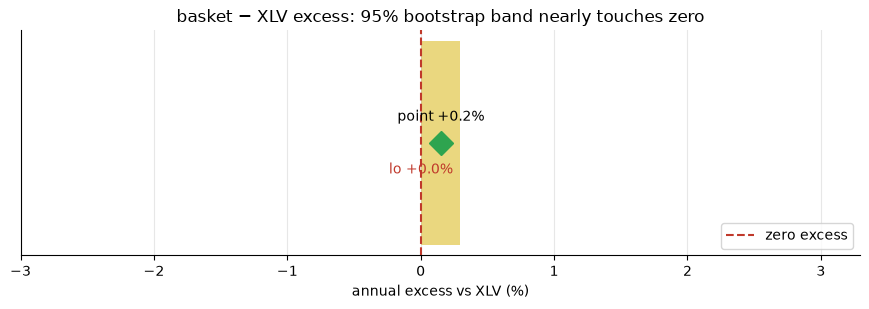

point +0.2%/yr   95% CI [+0.0%, +0.3%]   P(>0)=0.976


In [3]:
if HAVE_REAL:
    bb = st.block_bootstrap_excess(BK, RET['XLV'])
    pt, lo, hi, pp = bb['point'], bb['lo'], bb['hi'], bb['p_pos']
else:
    pt, lo, hi, pp = R['boot_pt'], R['boot_lo'], R['boot_hi'], R['boot_p']
fig, ax = plt.subplots(figsize=(8.8,3.2))
ax.barh([0],[hi-lo],left=[lo],height=.32,color=AMBER,alpha=.55)
ax.plot([pt],[0],'D',ms=12,c=GREEN); ax.axvline(0,c=RED,ls='--',label='zero excess')
ax.annotate(f'point +{pt:.1f}%',(pt,0),xytext=(0,16),textcoords='offset points',ha='center')
ax.annotate(f'lo +{lo:.1f}%',(lo,0),xytext=(0,-22),textcoords='offset points',ha='center',c=RED)
ax.set_yticks([]); ax.set_xlabel('annual excess vs XLV (%)'); ax.set_xlim(min(-3,lo-3),hi+3)
ax.set_title('basket − XLV excess: 95% bootstrap band nearly touches zero'); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()
print(f'point +{pt:.1f}%/yr   95% CI [+{lo:.1f}%, +{hi:.1f}%]   P(>0)={pp:.3f}')

> 💡 In plain words: the basket−XLV excess is **+15.1%/yr**, but its 95% band is **[+0.2%, +29.3%]** — the lower edge sits a hair above zero. Combined with the sub-2 *t* vs SPY, the single benchmark it 'beats' is the narrow one, fragilely. Now add the selection bias (these names were chosen *because* they won, which inflates the excess) and the honest stamp is **WEAK**, not REAL.

### 4c · The α is one name — the decomposition

Per-constituent market-model α vs SPY. A *theme* edge should be shared; a *single-stock* bet shows it all in one bar.

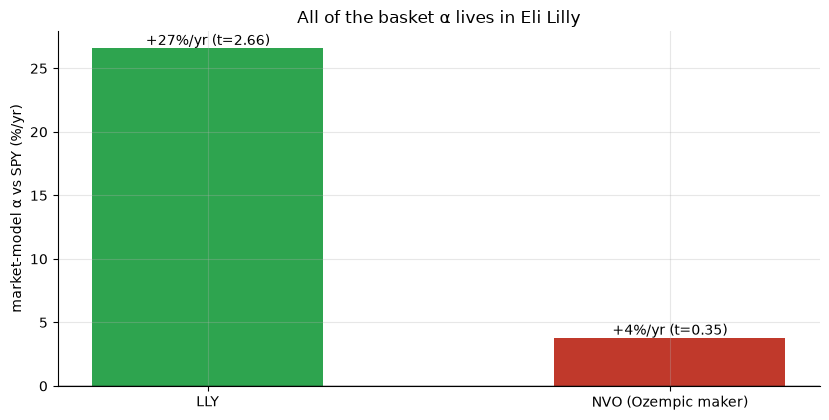

LLY α +26.6%/yr t=2.66   |   NVO α +3.8%/yr t=0.35


In [4]:
if HAVE_REAL:
    mL=st.market_model(RET['LLY'],RET['SPY']); mN=st.market_model(RET['NVO'],RET['SPY'])
    aL,tL=mL['alpha_ann']*100,mL['t_alpha']; aN,tN=mN['alpha_ann']*100,mN['t_alpha']
else:
    aL,tL,aN,tN = R['lly_alpha'],R['lly_ta'],R['nvo_alpha'],R['nvo_ta']
fig, ax = plt.subplots(figsize=(8.4,4.3))
bars=ax.bar(['LLY','NVO (Ozempic maker)'],[aL,aN],color=[GREEN, RED],width=.5)
ax.axhline(0,c='k',lw=1); ax.set_ylabel('market-model α vs SPY (%/yr)')
ax.set_title('All of the basket α lives in Eli Lilly')
for b,(v,t) in zip(bars,[(aL,tL),(aN,tN)]): ax.annotate(f'{v:+.0f}%/yr (t={t:.2f})',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'LLY α {aL:+.1f}%/yr t={tL:.2f}   |   NVO α {aN:+.1f}%/yr t={tN:.2f}')

> 💡 In plain words: **LLY** α = +26.6%/yr at *t* = **2.66** (a real single-name edge); **NVO** α = +3.8%/yr at *t* = **0.35** — statistically zero, despite being *the* Ozempic stock. The 'basket' is Lilly carrying a passenger. **H₂ rejected** — `MISATTRIBUTED`.

### 4d · The recency split — the excess flips sign

Annualised excess vs SPY, before vs during the GLP-1 mania (cut at 2023-01-01).

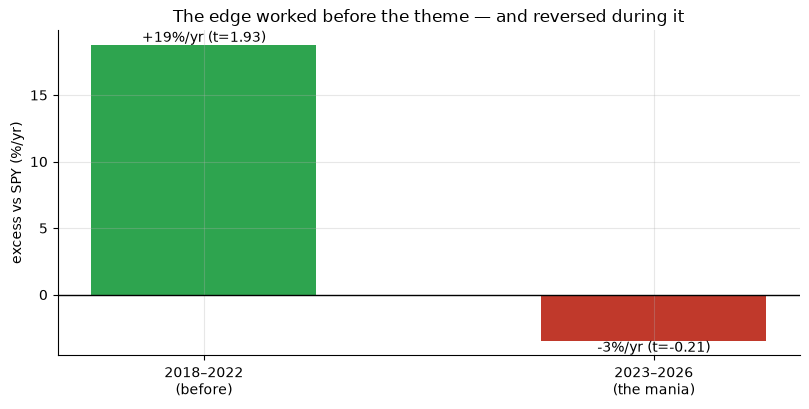

2018-2022: +18.8%/yr (t=1.93)   2023-2026: -3.5%/yr (t=-0.21)


In [5]:
if HAVE_REAL:
    pre = RET.index < '2023-01-01'; post = ~pre
    ep = st.excess_test(BK[pre], RET['SPY'][pre]); eq = st.excess_test(BK[post], RET['SPY'][post])
    preex,pret = ep['ann_excess']*100, ep['t_hac']; postex,postt = eq['ann_excess']*100, eq['t_hac']
else:
    preex,pret,postex,postt = R['pre_ex'],R['pre_t'],R['post_ex'],R['post_t']
fig, ax = plt.subplots(figsize=(8.2,4.2))
bars=ax.bar(['2018–2022\n(before)','2023–2026\n(the mania)'],[preex,postex],color=[GREEN,RED],width=.5)
ax.axhline(0,c='k',lw=1); ax.set_ylabel('excess vs SPY (%/yr)')
ax.set_title('The edge worked before the theme — and reversed during it')
for b,(v,t) in zip(bars,[(preex,pret),(postex,postt)]): ax.annotate(f'{v:+.0f}%/yr (t={t:.2f})',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'2018-2022: {preex:+.1f}%/yr (t={pret:.2f})   2023-2026: {postex:+.1f}%/yr (t={postt:.2f})')

> 💡 In plain words: **+19%/yr** before 2023, **-3.5%/yr** during the mania — a **sign flip** across a justified split. The trade's edge predates the story it's sold with; once the theme was a named, ETF-ified trade, it *underperformed* the market. **H₃ rejected.** This is the `MIXED`/regime-conditioned signature, not a durable premium.

### 4e · Tradability — costs are a red herring; concentration is the killer

One-way cost sweep on rebalancing turnover (vs XLV), and the drawdown of a two-name book.

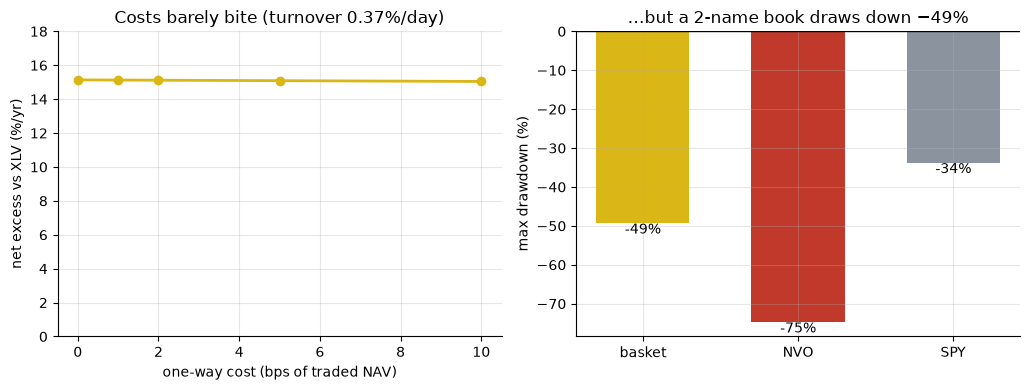

turnover 0.367%/day | net-of-10bp excess vs XLV 15.04%/yr | basket maxDD -49%


In [6]:
if HAVE_REAL:
    sweep = st.cost_sweep(BK, RET['XLV'], RET); tpd = st.turnover_per_day(RET)*100
    bps=[s['bps'] for s in sweep]; exc=[s['ann_excess']*100 for s in sweep]
    dds=[st.max_drawdown(BK)*100, st.max_drawdown(RET['NVO'])*100, st.max_drawdown(RET['SPY'])*100]
else:
    bps=[0,1,2,5,10]; exc=[R['ex_xlv'],R['ex_xlv'],R['ex_xlv']-0.02,R['ex_xlv']-0.05,R['cost10_ex']]; tpd=R['turnover']
    dds=[R['bk_dd'],R['nvo_dd'],R['spy_dd']]
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.4,4.0))
a1.plot(bps,exc,'o-',c=AMBER,lw=2); a1.set_xlabel('one-way cost (bps of traded NAV)')
a1.set_ylabel('net excess vs XLV (%/yr)'); a1.set_ylim(0,18); a1.set_title(f'Costs barely bite (turnover {tpd:.2f}%/day)')
a2.bar(['basket','NVO','SPY'],dds,color=[AMBER,RED,GREY],width=.6); a2.axhline(0,c='k',lw=1)
a2.set_ylabel('max drawdown (%)'); a2.set_title('…but a 2-name book draws down −49%')
for i,v in enumerate(dds): a2.annotate(f'{v:.0f}%',(i,v),ha='center',va='top')
plt.tight_layout(); plt.show()
print(f'turnover {tpd:.3f}%/day | net-of-10bp excess vs XLV {exc[-1]:.2f}%/yr | basket maxDD {dds[0]:.0f}%')

> 💡 In plain words: at **0.37%/day** turnover, even 10bp one-way leaves the excess essentially unchanged (+15.0%/yr). The idea doesn't die to the spread — it dies to **concentration**: a **-49%** drawdown on two correlated names betting one product cycle. That is beta to a story, uninvestable as a *scalable, diversified edge.* **Tradability — MIRAGE.**

### 4f · Faithful-engine control — recover the planted α (and its absence)

A deterministic one-factor panel plants a known per-name α; the market-model engine must find it where present and *not* find it where it's zero.

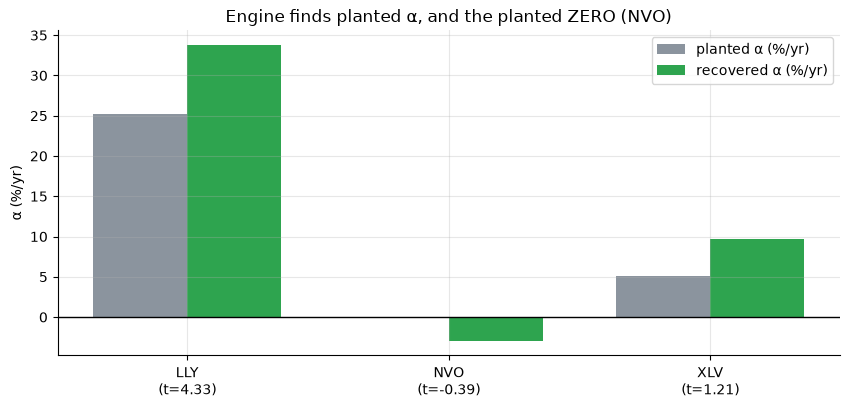

LLY: planted +25.2%/yr  recovered +33.8%/yr  t=4.33
NVO: planted +0.0%/yr  recovered -2.9%/yr  t=-0.39
XLV: planted +5.0%/yr  recovered +9.7%/yr  t=1.21


In [7]:
S = data.synthetic_panel()
rows = []
for nm, planted in [('LLY',0.0010*252),('NVO',0.0),('XLV',0.0002*252)]:
    mm = st.market_model(S[nm], S['SPY']); rows.append((nm, planted*100, mm['alpha_ann']*100, mm['t_alpha']))
x=np.arange(len(rows)); fig,ax=plt.subplots(figsize=(8.6,4.2))
ax.bar(x-.18,[r[1] for r in rows],.36,color=GREY,label='planted α (%/yr)')
ax.bar(x+.18,[r[2] for r in rows],.36,color=GREEN,label='recovered α (%/yr)')
ax.set_xticks(x); ax.set_xticklabels([f'{r[0]}\n(t={r[3]:.2f})' for r in rows])
ax.axhline(0,c='k',lw=1); ax.set_ylabel('α (%/yr)'); ax.set_title('Engine finds planted α, and the planted ZERO (NVO)')
ax.legend(); plt.tight_layout(); plt.show()
for nm,pl,rec,t in rows: print(f'{nm}: planted {pl:+.1f}%/yr  recovered {rec:+.1f}%/yr  t={t:.2f}')

> 💡 In plain words: the engine flags the planted edge (LLY-like, large *t*) and correctly **fails to find** α where none was planted (NVO-like, *t* ≈ 0) — to Monte-Carlo error. That's a *machinery* proof the decomposition isn't an artefact; it is **not** market evidence (a synthetic Sharpe never supports a Signal stamp).

## 5 · The verdict

- **Signal `WEAK`** — mean excess vs SPY +9.7%/yr at HAC-*t* = 1.10 (< 2); market-model α vs SPY *t* = 1.78. The lone *t* ≈ 2 (vs XLV) has a bootstrap CI **[+0.2%, +29.3%]** grazing zero, and the names were chosen post-hoc (selection biases it up). Literature/headline says alpha; this tape can't certify it.
- **Tradability `MIRAGE`** — a two-name book (corr 0.40), basket max-DD **-49%**, riding one product cycle. Costs immaterial (0.37%/day turnover); concentration, not the spread, is fatal to scaling it as an edge.
- **Two stocks & a story? `MISATTRIBUTED`** — α is all LLY (*t* = 2.66); NVO, the Ozempic maker, contributes none (*t* = 0.35) and is -69% off its high; and the excess flips to -3.5%/yr during the 2023–26 mania the theme is named for.

## 6 · Could you trade it? — the risk-adjusted reality

Even granting the raw return, what did you *earn per unit of risk*, and how does it compare once you account for the market exposure you were paid for anyway? Sharpe of each book (rf = 0), with the basket's β to SPY noted.

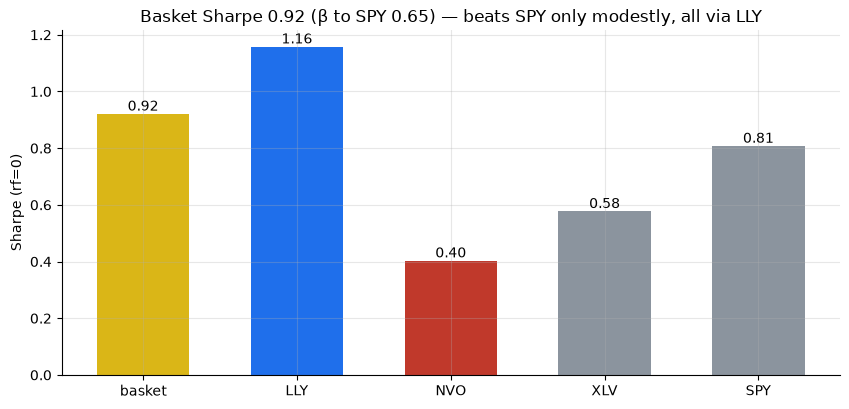

Sharpe: {'basket': 0.92, 'LLY': 1.16, 'NVO': 0.4, 'XLV': 0.58, 'SPY': 0.81} | basket beta to SPY 0.65


In [8]:
if HAVE_REAL:
    shp = {n: st.perf(RET[n])['sharpe'] for n in ['LLY','NVO','XLV','SPY']}
    shp['basket'] = st.perf(BK)['sharpe']; beta = st.market_model(BK, RET['SPY'])['beta']
else:
    shp = {'LLY':R['lly_sh'],'NVO':R['nvo_sh'],'XLV':R['xlv_sh'],'SPY':R['spy_sh'],'basket':R['bk_sh']}; beta=R['beta_spy']
order=['basket','LLY','NVO','XLV','SPY']; vals=[shp[k] for k in order]
fig,ax=plt.subplots(figsize=(8.6,4.2))
cols=[AMBER,'#1f6feb',RED,GREY,GREY]
bars=ax.bar(order,vals,color=cols,width=.6); ax.set_ylabel('Sharpe (rf=0)')
ax.set_title(f'Basket Sharpe {shp["basket"]:.2f} (β to SPY {beta:.2f}) — beats SPY only modestly, all via LLY')
for b,v in zip(bars,vals): ax.annotate(f'{v:.2f}',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print('Sharpe:', {k:round(shp[k],2) for k in order}, '| basket beta to SPY', round(beta,2))

> 💡 In plain words: the basket Sharpe (**0.92**) edges SPY's (**0.81**) — but it carries β ≈ 0.65 to the market and a -49% drawdown, and LLY's Sharpe (1.16) is the whole story (NVO's is 0.40). A modest Sharpe bump that's one stock and a deep tail isn't a strategy you'd allocate to; it's a concentrated bet you got paid for *this once.*

## 7 · Going further

- **A diversified GLP-1 basket.** Add the obesity-drug ETFs and the named 'GLP-1 losers' (food, dialysis, insulin-pump shorts); re-test whether a *broad* theme α clears *t* = 2 vs SPY — or still collapses to LLY.
- **Selection-clean construction.** Form the basket from the GLP-1 hopefuls as of 2018 (no hindsight), equal-weight, and rebalance on a rule. That is the honest counterfactual to a winner-picked basket (Brown et al. 1992).
- **NVO ADR vs the home line.** Re-run with the Copenhagen B-share in DKK (FX-hedged) to separate the company's fundamentals from ADR/FX effects in the −69% drawdown.

*The reproducible core is offline and deterministic. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*